## logistic function is a linear regression is a type of sigmoid, a call of function with the same specific properties.sigmoid  is a mathematical function that take any real numbers and maps to probability betweeen 1 and 0

In [2]:
import numpy as np
import matplotlib.pyplot as plt

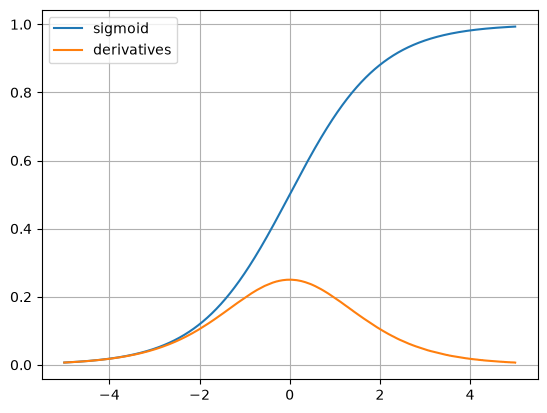

In [3]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
def derivatives(x,steps):
    return(sigmoid(x+steps)-sigmoid(x))/steps
x=np.linspace(-5,5,1000)
y1=sigmoid(x)
y2=derivatives(x,0.000000000001)
plt.plot(x,y1,label='sigmoid')
plt.plot(x,y2,label='derivatives')
plt.legend()
plt.grid()
plt.show()

## Logistic function does not predict a class directly (0 or 1) it predict the probability that a samplebelong to class 1

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [5]:
import seaborn as sns

In [6]:
df=sns.load_dataset('titanic')

In [7]:
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [8]:
print(df.shape)
print(df.info())

(891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB
None


In [9]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [11]:
x=df[['pclass','sex','age','fare']]
x.head()

,pclass,sex,age,fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


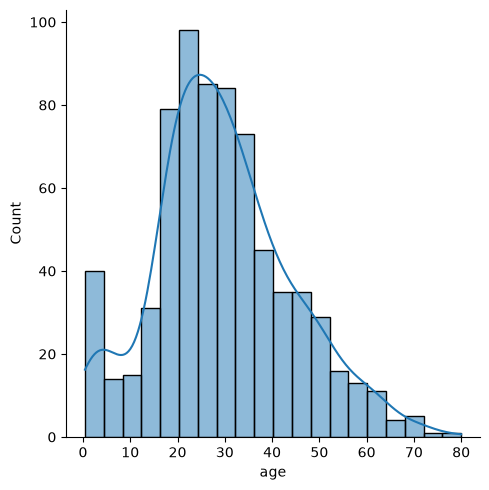

In [12]:
sns.displot(data=df,x='age',kde=True)

In [13]:
print(df['age'].mean())
print(df['age'].median())

29.69911764705882
28.0


In [14]:
y=df['survived']

In [15]:
print(x.isnull().sum())

pclass      0
sex         0
age       177
fare        0
dtype: int64


In [16]:
x=df[['pclass','sex','age','fare']].copy()

In [17]:
x['age']=x['age'].fillna(x['age'].median())

In [18]:
print(x.isnull().sum())

pclass    0
sex       0
age       0
fare      0
dtype: int64


<Figure size 1200x600 with 0 Axes>

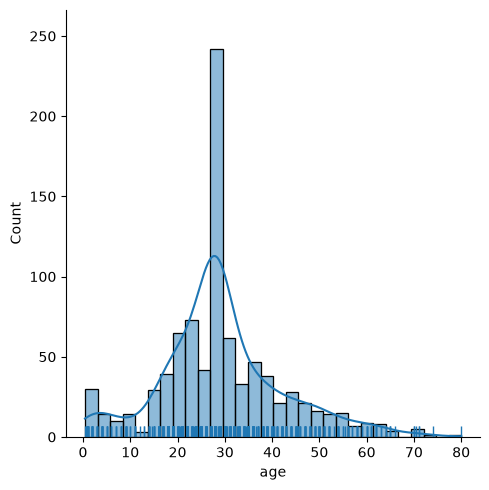

In [19]:
plt.figure(figsize=(12,6))
sns.displot(data=x,x='age',kde=True,rug=True)

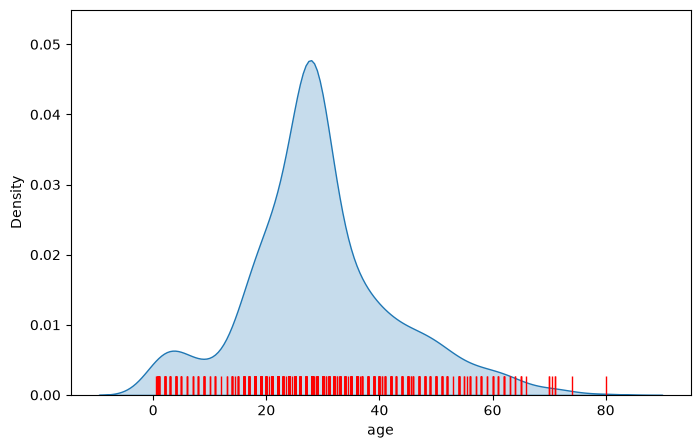

In [20]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=x,x='age',fill=True)
sns.rugplot(data=x,x='age',height=0.05,color='red')
plt.show()

<Axes: xlabel='fare', ylabel='Density'>

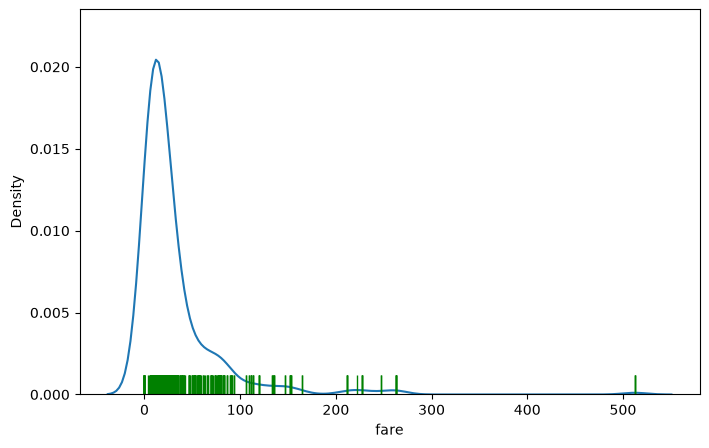

In [21]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=x,x='fare')
sns.rugplot(data=x,x='fare',height=0.05,color='green')

C:\Users\Student\AppData\Local\Temp\ipykernel_12324\1751260966.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=x,x='pclass',palette=['red','green','blue'])


<Axes: xlabel='pclass', ylabel='count'>

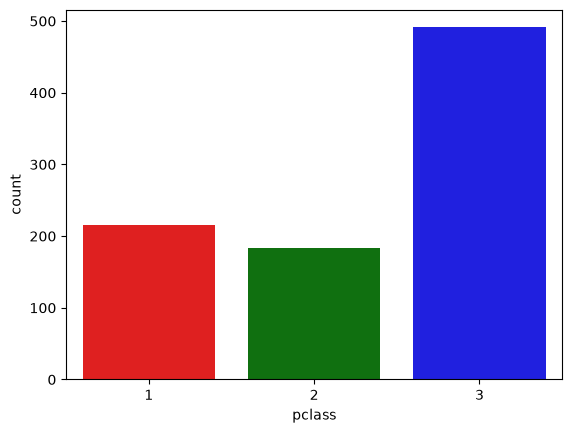

In [22]:
sns.countplot(data=x,x='pclass',palette=['red','green','blue'])

<Axes: xlabel='pclass', ylabel='count'>

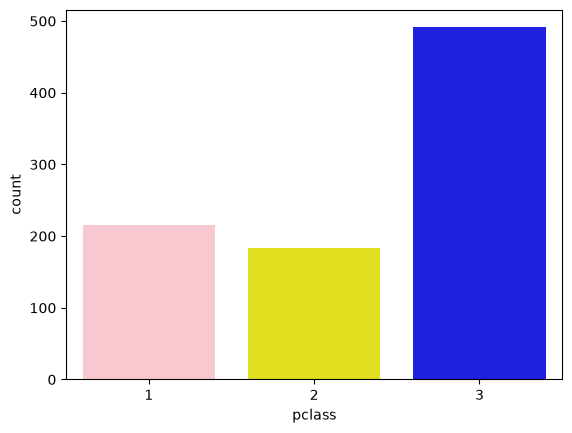

In [23]:
import warnings
warnings.filterwarnings('ignore')
sns.countplot(data=x,x='pclass',palette=['pink','yellow','blue'])

In [24]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

<Axes: >

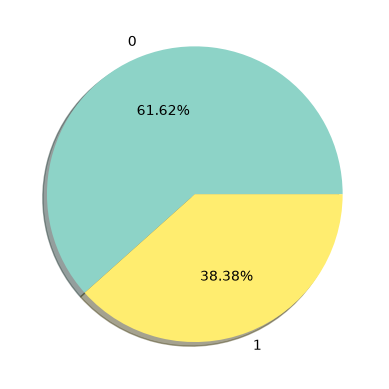

In [25]:
df['survived'].value_counts().plot(kind='pie',autopct='%1.2f%%',shadow=True,cmap='Set3')

In [26]:
print(df[(df['pclass']==3)&(df['survived']==0)].shape[0])
print(df[(df['pclass']==2)&(df['survived']==0)].shape[0])
print(df[(df['pclass']==1)&(df['survived']==0)].shape[0])

372
97
80


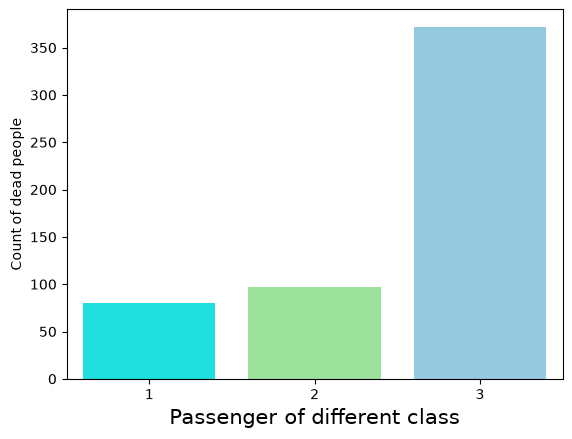

In [27]:
dead=df[df['survived']==0]
sns.countplot(data=dead,x='pclass',order=[1,2,3],palette=['aqua','lightgreen','skyblue'])
plt.xlabel("Passenger of different class",fontsize=15)
plt.ylabel("Count of dead people")
plt.show()

<Axes: xlabel='pclass', ylabel='count'>

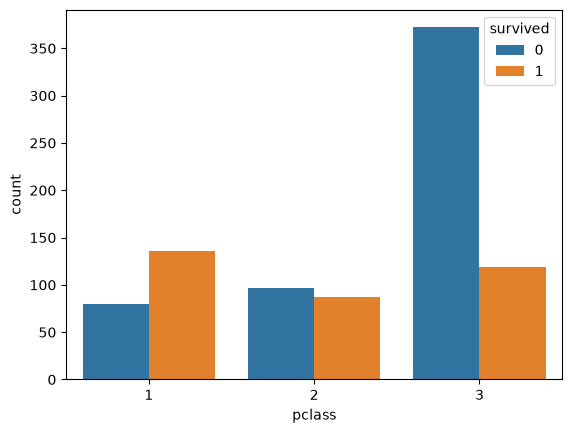

In [28]:
sns.countplot(data=df,x='pclass',hue='survived',order=[1,2,3])

<Axes: xlabel='sex'>

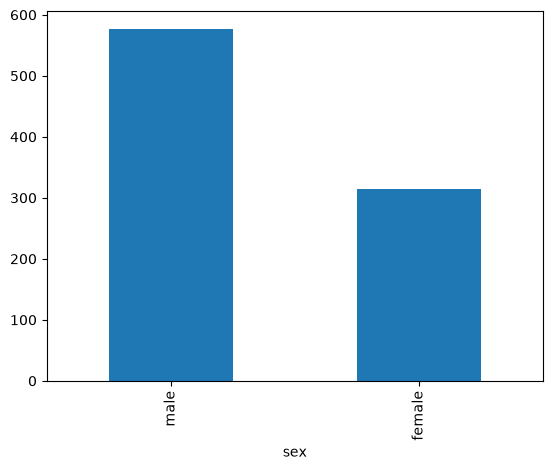

In [29]:
x['sex'].value_counts().plot(kind='bar')

In [30]:
print(df[(df['sex']=='male')&(df['survived']==0)].shape[0])
print(df[(df['sex']=='female')&(df['survived']==0)].shape[0])

468
81


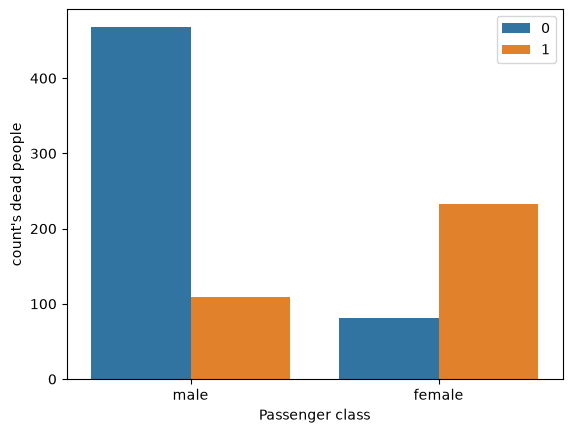

In [31]:
sns.countplot(data=df,x='sex',hue='survived',order=['male','female'])
plt.xlabel("Passenger class")
plt.ylabel("count's dead people")
plt.legend(loc='upper right')
plt.show()

In [32]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pclass  891 non-null    int64  
 1   sex     891 non-null    str    
 2   age     891 non-null    float64
 3   fare    891 non-null    float64
dtypes: float64(2), int64(1), str(1)
memory usage: 32.1 KB


In [33]:
x['sex']=(x['sex']=='male').astype(int)

In [34]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pclass  891 non-null    int64  
 1   sex     891 non-null    int64  
 2   age     891 non-null    float64
 3   fare    891 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [35]:
x_dummies=df[['pclass','sex','age','fare']]
x_dummies.head()

,pclass,sex,age,fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


In [36]:
from sklearn.preprocessing import LabelEncoder

In [37]:
le=LabelEncoder()

In [38]:
x_dummies['sex']=le.fit_transform(x_dummies['sex'])
x_dummies.head()

,pclass,sex,age,fare
0,3,1,22.0,7.2500
1,1,0,38.0,71.2833
2,3,0,26.0,7.9250
3,1,0,35.0,53.1000
4,3,1,35.0,8.0500


In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42,stratify=y)

In [40]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((712, 4), (712,), (179, 4), (179,))

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
sc=StandardScaler()

In [43]:
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.fit_transform(x_test)

In [44]:
x_train_scaled

array([[ 0.82956755,  0.74242727, -0.11207776,  0.5138115 ],
       [-0.37094484,  0.74242727, -0.11207776, -0.66256323],
       [-1.57145722,  0.74242727, -0.11207776,  3.95539858],
       ...,
       [ 0.82956755, -1.34693328,  1.42338169,  0.0532047 ],
       [-1.57145722,  0.74242727,  1.34660872,  0.13909685],
       [-1.57145722,  0.74242727, -0.11207776, -0.10973011]],
      shape=(712, 4))

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
log_reg = LogisticRegression()

In [47]:
log_reg.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [48]:
y_pred=log_reg.predict(x_test_scaled)

In [49]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[94, 16],
       [21, 48]])

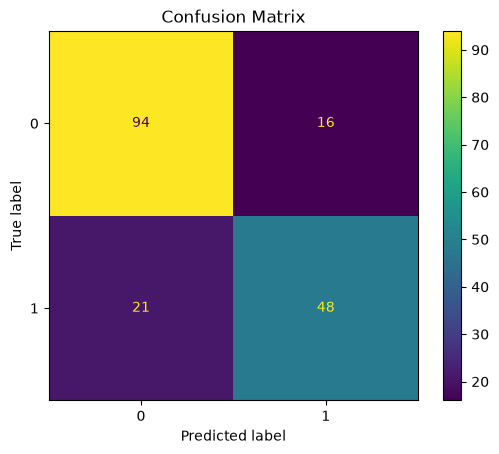

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.title("Confusion Matrix")
plt.show()

# A confusion matrix is a table used o evaluate a classification model by comparing the actual class and te predicted class .it shows both correct prediction and type of errors

In [55]:
print(accuracy_score(y_test,y_pred)*100)

79.3296089385475


In [56]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.70      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



## Probability Prediction

In [57]:
y_pred=log_reg.predict(x_test_scaled)

In [61]:
y_prob=log_reg.predict_proba(x_test_scaled)
y_prob=log_reg.predict_proba(x_test_scaled)[:,1]

In [62]:
## the models survival probabilities
fpr,tpr,thresholds=roc_curve(y_test,y_prob)

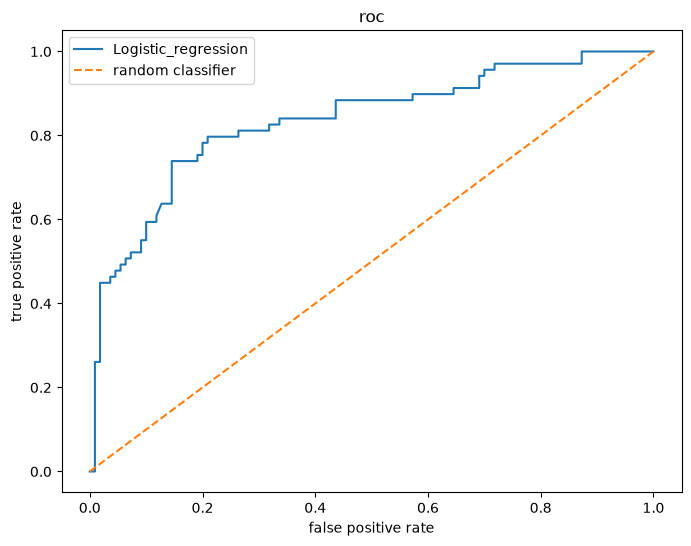

In [63]:
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label="Logistic_regression")
plt.plot([0,1],[0,1],linestyle='--',label="random classifier")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("roc")
plt.legend()
plt.show()

auc score 0.835836627140975


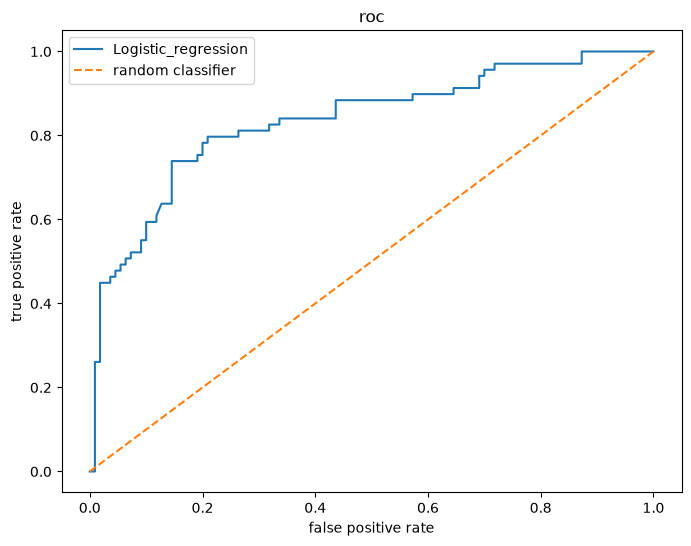

In [65]:
auc_score=roc_auc_score(y_test,y_prob)
print("auc score",auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label="Logistic_regression")
plt.plot([0,1],[0,1],linestyle='--',label="random classifier")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("roc")
plt.legend()
plt.show()

## roc and aug
roc stands for receiver operating characteristics